# OCT-C8 Retinal Disease Classification + CDS — end-to-end walkthrough

This notebook **presents the finished pipeline** by loading the artifacts the
Hydra entrypoints produce and the tested code in `src/oct_cds/`. It does not
reimplement any logic.

If an artifact is missing, the relevant cell prints the command to run.
To produce everything from scratch (from the repo root):

```bash
python -m oct_cds.cli data build --paths kaggle
python train.py   paths=kaggle
python eval.py    paths=kaggle
python eval.py    paths=kaggle eval.split=external_test
python explain.py paths=kaggle explain.split=external_test 'explain.classes=[Drusen]' explain.only_errors=true explain.target=both
python cds.py     paths=kaggle
python cds.py     paths=kaggle cds_run.split=external_test
```

Set the environment with `OCT_CDS_ENV` (`kaggle` or `default`).

In [1]:
import json, os, re, sys
from pathlib import Path

import pandas as pd

# anchor on the repo root regardless of where the notebook is opened / executed
REPO = Path.cwd().resolve()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

ENV = os.environ.get("OCT_CDS_ENV", "kaggle")   # "kaggle" | "default"

from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

GlobalHydra.instance().clear()
with initialize_config_dir(version_base=None, config_dir=str(REPO / "configs")):
    _cfg = compose(
        config_name="config",
        # pin paths.root_dir so ${hydra:runtime.cwd} is never evaluated outside a
        # `hydra.main` run (it would raise otherwise).
        overrides=[f"paths={ENV}", f"paths.root_dir={REPO.as_posix()}"],
    )
    cfg = OmegaConf.to_container(_cfg, resolve=True)
GlobalHydra.instance().clear()

OUTPUT_DIR  = Path(cfg["output_dir"])
DATA_DIR    = Path(cfg["paths"]["data_dir"])
EVAL_DIR    = OUTPUT_DIR / "eval"
CDS_DIR     = OUTPUT_DIR / "cds"
EXPLAIN_DIR = OUTPUT_DIR / "explain"

print("env       :", ENV)
print("repo      :", REPO)
print("output_dir:", OUTPUT_DIR)
print("data_dir  :", DATA_DIR)


def load_json(path):
    path = Path(path)
    if not path.exists():
        print(f"  (missing: {path})")
        return None
    return json.loads(path.read_text())


def show(df):
    """display() with a plain-text fallback when the Styler backend is absent."""
    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df)

env       : kaggle
repo      : /kaggle/working/OCT-Based-Retinal-Disease-Classification-and-AI-Clinical-Decision-Support
output_dir: /kaggle/working/oct_cds_outputs/oct_c8_densenet121
data_dir  : /kaggle/working/OCT-Based-Retinal-Disease-Classification-and-AI-Clinical-Decision-Support/data


## 1 · Dataset & manifests

OCT-C8 (authors' train/val/test split, 3,000 images/class) plus the 37-image
OPTOPOL clinic set locked to `external_test`.

In [2]:
csvs = {
    "train": "train.csv", "val": "val.csv", "test": "test.csv",
    "external_test": "external_clinic_optopol.csv",
}
frames = []
for split, name in csvs.items():
    f = DATA_DIR / "processed" / name
    if f.exists():
        d = pd.read_csv(f)
        d["split"] = split
        frames.append(d)

if frames:
    manifest = pd.concat(frames, ignore_index=True)
    counts = manifest.pivot_table(index="label_key", columns="split",
                                  values="image_path", aggfunc="count", fill_value=0)
    show(counts)
    print("totals:", manifest.groupby("split").size().to_dict())
else:
    print(f"no manifests — run:  python -m oct_cds.cli data build --paths {ENV}")

split,external_test,test,train,val
label_key,,,,
AMD,0,350,2300,350
CNV,1,350,2300,350
CSR,0,350,2300,350
DME,5,350,2300,350
DR,0,350,2300,350
Drusen,22,350,2300,350
Macular Hole,0,350,2300,350
Normal,9,350,2300,350


totals: {'external_test': 37, 'test': 2800, 'train': 18400, 'val': 2800}


## 2 · Model architecture

DenseNet-121 (ImageNet-pretrained) with a fresh 8-class head, loaded from the
best checkpoint via the same `load_classifier` helper the entrypoints use.

In [3]:
from oct_cds.data.label_map import load_label_map
from oct_cds.models.loading import load_classifier, resolve_ckpt

lm = load_label_map()
model = ckpt = None
try:
    ckpt = resolve_ckpt(cfg["eval"].get("ckpt_path"), OUTPUT_DIR)
    model = load_classifier(ckpt, cfg["model"], cfg["training"])
    n_params = sum(p.numel() for p in model.parameters())
    print(f"backbone  : {cfg['model']['timm_name']}  (pretrained={cfg['model']['pretrained']})")
    print(f"classes   : {lm.num_classes}  ->  {lm.keys}")
    print(f"parameters: {n_params/1e6:.2f}M")
    print(f"checkpoint: {ckpt.name}")
    _f1 = re.findall(r"[0-9]*\.[0-9]+", ckpt.name)
    if _f1:
        print(f"val macro-F1 at best epoch: {_f1[-1]}")
except SystemExit as e:
    print("no checkpoint yet:", e, f"\nrun:  python train.py paths={ENV}")

22:48:47 | INFO    | oct_cds.models.loading | auto-selected checkpoint: /kaggle/working/oct_cds_outputs/oct_c8_densenet121/checkpoints/epoch=17-val/macro_f1=0.9236.ckpt


22:48:49 | INFO    | timm.models._builder | Loading pretrained weights from Hugging Face hub (timm/densenet121.ra_in1k)


22:48:50 | INFO    | httpx | HTTP Request: HEAD https://huggingface.co/timm/densenet121.ra_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"


22:48:50 | INFO    | timm.models._hub | [timm/densenet121.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


22:48:50 | INFO    | timm.models._builder | Missing keys (classifier.weight, classifier.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


backbone  : densenet121  (pretrained=True)
classes   : 8  ->  ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'Drusen', 'Macular Hole', 'Normal']
parameters: 6.96M
checkpoint: macro_f1=0.9236.ckpt
val macro-F1 at best epoch: 0.9236


## 3 · Held-out test set (OCT-C8, 2,800 images)

Headline metrics + per-class breakdown + confusion matrix, from
`eval/metrics_test.json` / `confusion_test.csv` (produced by `eval.py`).

In [4]:
rep = load_json(EVAL_DIR / "metrics_test.json")
if rep:
    b = rep.get("calibrated", rep["uncalibrated"])
    head = pd.DataFrame({
        "metric": ["accuracy", "macro_f1", "balanced_accuracy", "quadratic_weighted_kappa",
                   "auroc_macro", "auprc_macro", "ECE (uncalibrated)", "ECE (calibrated)"],
        "value": [b["accuracy"], b["macro_f1"], b["balanced_accuracy"], b["quadratic_weighted_kappa"],
                  b.get("auroc_macro"), b.get("auprc_macro"),
                  rep["ece_uncalibrated"], rep.get("ece_calibrated")],
    })
    head["value"] = head["value"].map(lambda v: round(v, 4) if isinstance(v, (int, float)) else v)
    show(head)
    show(pd.DataFrame(b["per_class"]).T)
else:
    print(f"run:  python eval.py paths={ENV}")

,metric,value
0,accuracy,0.9646
1,macro_f1,0.9646
2,balanced_accuracy,0.9646
3,quadratic_weighted_kappa,0.9652
4,auroc_macro,0.9968
5,auprc_macro,0.9852
6,ECE (uncalibrated),0.0353
7,ECE (calibrated),0.0064


,sensitivity,specificity,precision,f1,support,auroc,auprc
AMD,1.000000,1.000000,1.000000,1.000000,350.0,1.000000,1.000000
CNV,0.934286,0.982041,0.881402,0.907074,350.0,0.994247,0.971495
CSR,1.000000,1.000000,1.000000,1.000000,350.0,1.000000,1.000000
DME,0.914286,0.992653,0.946746,0.930233,350.0,0.991317,0.969004
DR,1.000000,1.000000,1.000000,1.000000,350.0,1.000000,1.000000
Drusen,0.891429,0.994694,0.960000,0.924444,350.0,0.992999,0.959023
Macular Hole,1.000000,1.000000,1.000000,1.000000,350.0,1.000000,1.000000
Normal,0.977143,0.990204,0.934426,0.955307,350.0,0.995652,0.982326


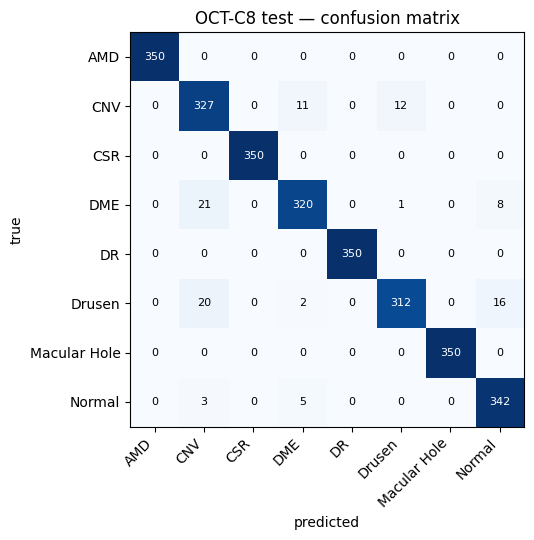

In [5]:
cm_csv = EVAL_DIR / "confusion_test.csv"
if cm_csv.exists():
    import matplotlib.pyplot as plt
    cm = pd.read_csv(cm_csv, index_col=0)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.imshow(cm.values, cmap="Blues")
    ax.set_xticks(range(len(cm.columns)))
    ax.set_xticklabels(cm.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(cm.index)))
    ax.set_yticklabels(cm.index)
    _thr = cm.values.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm.values[i, j]
            ax.text(j, i, v, ha="center", va="center", fontsize=8,
                    color="white" if v > _thr else "black")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title("OCT-C8 test — confusion matrix")
    plt.tight_layout()
    plt.show()
else:
    print("no confusion_test.csv yet")

## 4 · External validation (OPTOPOL REVO clinic scans, 37 images)

Different device family → domain shift. Only 4 of 8 classes are represented;
see [LIMITATIONS.md](../LIMITATIONS.md).

In [6]:
ext = load_json(EVAL_DIR / "metrics_external_test.json")
if ext:
    b = ext.get("calibrated", ext["uncalibrated"])
    print(f"n={ext['n_images']}   accuracy={b['accuracy']:.4f}   macro-F1={b['macro_f1']:.4f}")
    pc = pd.DataFrame(b["per_class"]).T
    show(pc[pc["support"] > 0])
    never = [k for k in lm.keys if b["per_class"][k]["support"] == 0]
    print("classes with 0 external scans (never externally validated):", never)
else:
    print(f"run:  python eval.py paths={ENV} eval.split=external_test")

n=37   accuracy=0.5946   macro-F1=0.3932


,sensitivity,specificity,precision,f1,support,auroc,auprc
CNV,1.000000,0.888889,0.200000,0.333333,1.0,1.000000,1.000000
DME,0.800000,0.968750,0.800000,0.800000,5.0,0.981250,0.876667
Drusen,0.363636,1.000000,1.000000,0.533333,22.0,0.933333,0.957445
Normal,1.000000,0.714286,0.529412,0.692308,9.0,0.928571,0.819913


classes with 0 external scans (never externally validated): ['AMD', 'CSR', 'DR', 'Macular Hole']


## 5 · Grad-CAM — misclassified clinic Drusen

`[ raw B-scan | Grad-CAM heatmap ]` strips from `explain.py`
(`explain.target=both` writes one `cam-pred-*` and one `cam-true-*` file per
scan). Reviewed pattern: **correct localisation, wrong classification** — in 3 of
4 pairs the predicted- and true-class heatmaps land in nearly the same place.

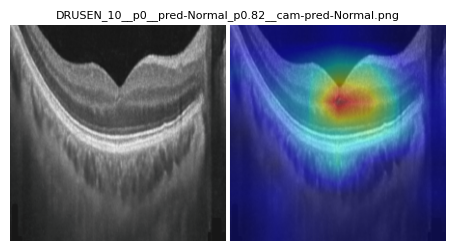

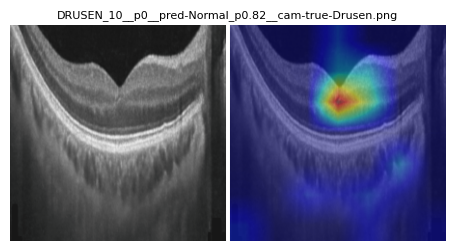

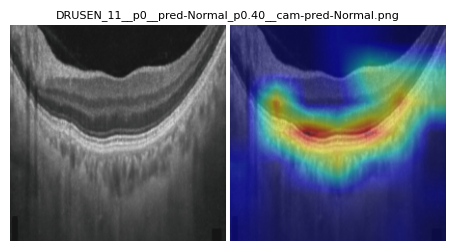

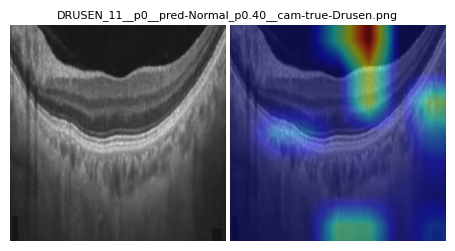

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

cam_dir = EXPLAIN_DIR / "external_test" / "wrong" / "Drusen"
pngs = sorted(cam_dir.glob("*.png"))[:4] if cam_dir.is_dir() else []
if not pngs and (EXPLAIN_DIR / "test").is_dir():
    pngs = sorted((EXPLAIN_DIR / "test").rglob("wrong/*/*.png"))[:4]

if pngs:
    for p in pngs:
        plt.figure(figsize=(9, 2.8))
        plt.imshow(Image.open(p))
        plt.axis("off")
        plt.title(p.name, fontsize=8)
        plt.show()
else:
    print(f"no overlays — run:  python explain.py paths={ENV} explain.split=external_test "
          f"'explain.classes=[Drusen]' explain.only_errors=true explain.target=both")

## 6 · CDS layer output

Calibrated predictions run through the rule engine. Headline: on the images the
model got **wrong**, did CDS defer to a specialist (good) or assert a confident
wrong triage (bad)? See [LIMITATIONS.md](../LIMITATIONS.md) for the MSP-confidence gap.

In [8]:
for split in ["test", "external_test"]:
    s = load_json(CDS_DIR / f"summary_{split}.json")
    if not s:
        suffix = "" if split == "test" else f" cds_run.split={split}"
        print(f"run:  python cds.py paths={ENV}{suffix}")
        continue
    print(f"\n=== CDS · {split}   n={s['n_images']}  model_acc={s['model_accuracy']} ===")
    print("urgency mix     :", s["urgency_distribution"])
    print("abstention rate :", s["abstention_rate"], "  ood-reject rate:", s["ood_reject_rate"])
    m = s["on_misclassified"]
    print(f"MISCLASSIFIED n={m['n']}:  deferred={m['deferred_to_specialist']}  "
          f"confident wrong call={m['confident_call']}  {m['confident_call_urgencies']}")
    if s["misclassified_by_true_class"]:
        show(pd.DataFrame(s["misclassified_by_true_class"]).T)


=== CDS · test   n=2800  model_acc=0.9646 ===
urgency mix     : {'soon': 1107, 'urgent': 1012, 'routine': 320, 'none': 361}
abstention rate : 0.0204   ood-reject rate: 0.0
MISCLASSIFIED n=99:  deferred=36  confident wrong call=63  {'urgent': 32, 'routine': 12, 'none': 19}


,n,deferred_to_specialist,confident_call,confident_call_urgencies
CNV,23,4,19,"{'urgent': 8, 'routine': 11}"
DME,30,12,18,"{'urgent': 9, 'none': 8, 'routine': 1}"
Drusen,38,17,21,"{'none': 11, 'urgent': 10}"
Normal,8,3,5,{'urgent': 5}



=== CDS · external_test   n=37  model_acc=0.5946 ===
urgency mix     : {'urgent': 8, 'none': 16, 'soon': 7, 'routine': 6}
abstention rate : 0.1622   ood-reject rate: 0.0
MISCLASSIFIED n=15:  deferred=4  confident wrong call=11  {'urgent': 3, 'none': 7, 'soon': 1}


,n,deferred_to_specialist,confident_call,confident_call_urgencies
DME,1,0,1,{'urgent': 1}
Drusen,14,4,10,"{'none': 7, 'urgent': 2, 'soon': 1}"


---

**Summary.** DenseNet-121 reaches 96.5% accuracy / macro-F1 and 0.6% calibrated
ECE on the OCT-C8 test set, but drops to ~59% on OPTOPOL clinic scans (device
domain shift), and the MSP-based CDS confidence does not reliably catch the
confident-but-wrong predictions that shift produces. Full write-up in
[README.md](../README.md#results); caveats in [LIMITATIONS.md](../LIMITATIONS.md).